In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Computer ka default home rasta nikalna
home = os.path.expanduser("~")

# 2. Dono possible raston (Normal Desktop aur OneDrive Desktop) ki list
possible_paths = [
    os.path.join(home, "Desktop", "Fraud Detection_Afjal Alam", "data"),
    os.path.join(home, "OneDrive", "Desktop", "Fraud Detection_Afjal Alam", "data")
]

# 3. Sahi rasta dhoondhna
valid_path = None
for path in possible_paths:
    if os.path.exists(path):
        valid_path = path
        break

if valid_path:
    print(f"Success! Data folder yahan mil gaya: {valid_path}\n")
    print("Files load ho rahi hain (kripya thoda wait karein)...")
    
    # 4. Data Load aur Merge karna
    transaction_file = os.path.join(valid_path, 'train_transaction.csv')
    identity_file = os.path.join(valid_path, 'train_identity.csv')
    
    df_transaction = pd.read_csv(transaction_file)
    df_identity = pd.read_csv(identity_file)
    
    df = pd.merge(df_transaction, df_identity, on='TransactionID', how='left')
    
    print(f"Data merge ho gaya! Total Rows aur Columns: {df.shape}")
    display(df.head())
    
else:
    print("Error: Folder abhi bhi nahi mila. Kripya Windows File Explorer mein 'data' folder open karein, upar address bar se uski poori location copy karein aur batayein.")

Success! Data folder yahan mil gaya: C:\Users\user\Desktop\Fraud Detection_Afjal Alam\data

Files load ho rahi hain (kripya thoda wait karein)...
Data merge ho gaya! Total Rows aur Columns: (590540, 434)


,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,...,samsung browser 6.2,32.0,2220x1080,match_status:2,T,F,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M


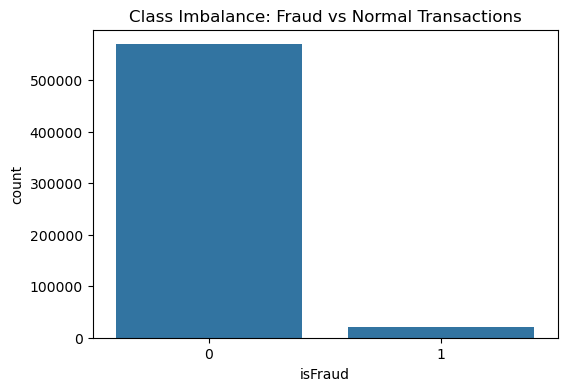

Total Transactions: 590540
Fraud Transactions: 20663
Actual Fraud Rate: 3.50%


In [2]:
# Create a bar plot to show the class imbalance
plt.figure(figsize=(6, 4))
sns.countplot(x='isFraud', data=df)
plt.title('Class Imbalance: Fraud vs Normal Transactions')
plt.show()

# Calculate and print the exact fraud percentage
fraud_count = df['isFraud'].sum()
total_count = len(df)
fraud_rate = (fraud_count / total_count) * 100

print(f"Total Transactions: {total_count}")
print(f"Fraud Transactions: {fraud_count}")
print(f"Actual Fraud Rate: {fraud_rate:.2f}%")

In [3]:
# Calculate the percentage of missing data in each column
missing_pct = df.isnull().mean() * 100

# Filter columns that have more than 50% missing values
cols_to_drop = missing_pct[missing_pct > 50].index

print(f"Total columns in dataset: {df.shape[1]}")
print(f"Columns with >50% missing values: {len(cols_to_drop)}")
print("\nThese columns contain too much missing data and will be dropped in Task 2.")

Total columns in dataset: 434
Columns with >50% missing values: 214

These columns contain too much missing data and will be dropped in Task 2.


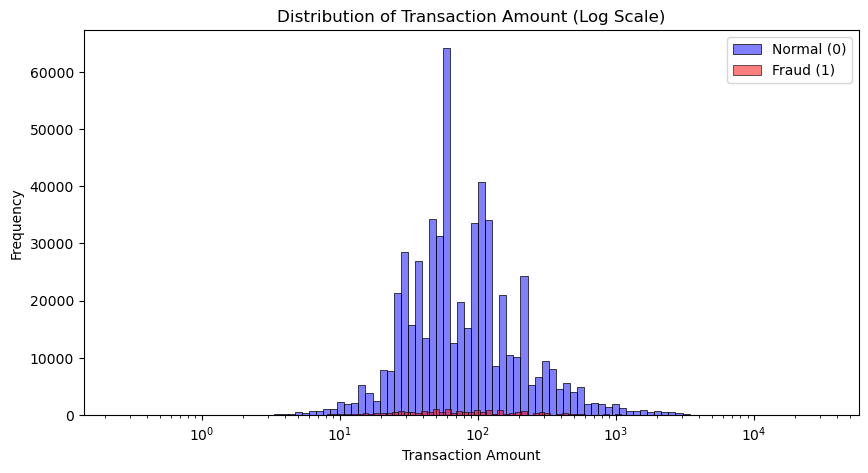

In [4]:
# Plot transaction amounts on a logarithmic scale
plt.figure(figsize=(10, 5))

# Plot normal transactions (isFraud == 0)
sns.histplot(df[df['isFraud']==0]['TransactionAmt'], bins=100, color='blue', alpha=0.5, label='Normal (0)', log_scale=True)

# Plot fraud transactions (isFraud == 1)
sns.histplot(df[df['isFraud']==1]['TransactionAmt'], bins=100, color='red', alpha=0.5, label='Fraud (1)', log_scale=True)

plt.title('Distribution of Transaction Amount (Log Scale)')
plt.xlabel('Transaction Amount')
plt.ylabel('Frequency')
plt.legend()
plt.show()

Calculating correlations (this may take a few seconds)...


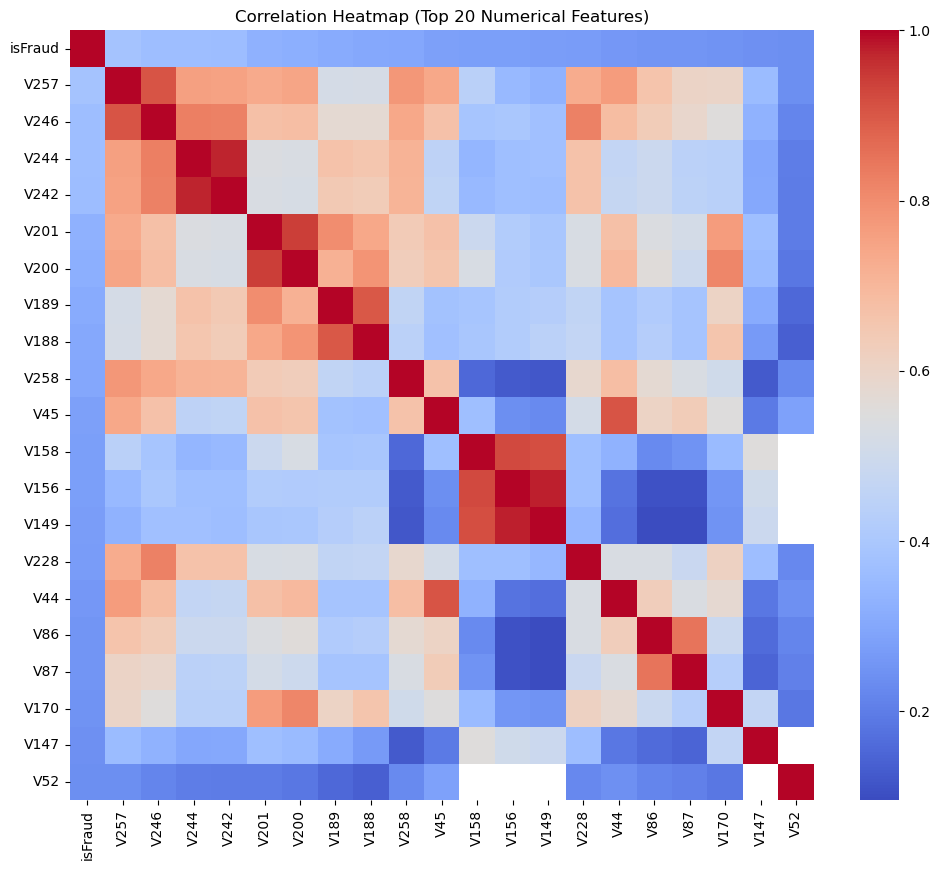

In [5]:
# Select only numerical columns for correlation
numeric_cols = df.select_dtypes(include=[np.number])

# Find the top 20 features most strongly correlated with 'isFraud'
print("Calculating correlations (this may take a few seconds)...")
top_features = numeric_cols.corr()['isFraud'].abs().sort_values(ascending=False).head(21).index

# Plot the heatmap for these top features
plt.figure(figsize=(12, 10))
sns.heatmap(df[top_features].corr(), annot=False, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap (Top 20 Numerical Features)')
plt.show()

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, RobustScaler
from imblearn.over_sampling import SMOTE
import numpy as np

print("1. Dropping columns with >50% missing values...")
df_clean = df.drop(columns=cols_to_drop)

print("2. Creating 3 engineered features...")
# Feature 1: Divide transaction amount by the mean amount
df_clean['AmtToMeanRatio'] = df_clean['TransactionAmt'] / df_clean['TransactionAmt'].mean()

# Feature 2: Extract hour of the day from Timestamp
df_clean['HourOfDay'] = np.floor(df_clean['TransactionDT'] / 3600) % 24

# Feature 3: DeviceRisk (Using original 'df' instead of 'df_clean' because it was dropped in Step 1)
# Logic: 0 (Low Risk) if DeviceInfo is missing/NaN, else 1 (High Risk)
df_clean['DeviceRisk'] = np.where(df['DeviceInfo'].isna(), 0, 1)

print("3. Imputing remaining missing values...")
# Get numerical and categorical columns
numeric_cols = df_clean.select_dtypes(include=[np.number]).columns
categorical_cols = df_clean.select_dtypes(include=['object']).columns

# Fill numerical columns with Median
for col in numeric_cols:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

# Fill categorical columns with Mode (most frequent value)
for col in categorical_cols:
    df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])

print("4. Converting text to numbers (Label Encoding)...")
le = LabelEncoder()
for col in categorical_cols:
    df_clean[col] = df_clean[col].astype(str)
    df_clean[col] = le.fit_transform(df_clean[col])

print("5. Splitting data into Train (80%) and Test (20%)...")
# Separate Target (y) and Features (X)
X = df_clean.drop(columns=['isFraud', 'TransactionID', 'TransactionDT'])
y = df_clean['isFraud']

# Stratify ensures the 3.5% fraud rate is maintained in both train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("6. Scaling data using RobustScaler...")
scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\n7. Applying SMOTE (Only on Training set)...")
print(f"Fraud ratio BEFORE SMOTE:\n{y_train.value_counts(normalize=True)}")

# SMOTE generates synthetic fraud data to create a 50-50 balance
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

print(f"\nFraud ratio AFTER SMOTE:\n{y_train_smote.value_counts(normalize=True)}")
print("\nTask 2 Complete! Data is perfectly preprocessed and ready for modeling.")

1. Dropping columns with >50% missing values...
2. Creating 3 engineered features...
3. Imputing remaining missing values...
4. Converting text to numbers (Label Encoding)...
5. Splitting data into Train (80%) and Test (20%)...
6. Scaling data using RobustScaler...

7. Applying SMOTE (Only on Training set)...
Fraud ratio BEFORE SMOTE:
isFraud
0    0.965011
1    0.034989
Name: proportion, dtype: float64

Fraud ratio AFTER SMOTE:
isFraud
0    0.5
1    0.5
Name: proportion, dtype: float64

Task 2 Complete! Data is perfectly preprocessed and ready for modeling.


In [9]:
import lightgbm as lgb
import xgboost as xgb
from sklearn.ensemble import IsolationForest
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, average_precision_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

print("1. Initializing the 3 Models...")
# LightGBM Classifier
lgbm_model = lgb.LGBMClassifier(random_state=42)

# XGBoost Classifier
xgb_model = xgb.XGBClassifier(random_state=42, eval_metric='logloss')

# Isolation Forest (Anomaly Detection)
# We expect roughly 3.5% fraud, so we set contamination=0.035
iso_forest = IsolationForest(random_state=42, contamination=0.035)

print("2. Training LightGBM (This is usually fast)...")
lgbm_model.fit(X_train_smote, y_train_smote)

print("3. Training XGBoost (This might take a few minutes. Please wait!)...")
xgb_model.fit(X_train_smote, y_train_smote)

print("4. Training Isolation Forest...")
# Note: Isolation Forest is trained on original scaled data, not the SMOTE data
iso_forest.fit(X_train_scaled)

print("5. Making Predictions on the 20% unseen Test Data...")
# LightGBM Predictions
y_pred_lgbm = lgbm_model.predict(X_test_scaled)
y_prob_lgbm = lgbm_model.predict_proba(X_test_scaled)[:, 1]

# XGBoost Predictions
y_pred_xgb = xgb_model.predict(X_test_scaled)
y_prob_xgb = xgb_model.predict_proba(X_test_scaled)[:, 1]

# Isolation Forest Predictions
# It returns -1 for anomalies (fraud) and 1 for normal. We map it to 1 and 0.
y_pred_iso = iso_forest.predict(X_test_scaled)
y_pred_iso = np.where(y_pred_iso == -1, 1, 0)

# Create a function to quickly evaluate and print metrics
def evaluate_model(name, y_true, y_pred, y_prob=None):
    print(f"\n========== {name} Performance ==========")
    print(f"Accuracy:  {accuracy_score(y_true, y_pred):.4f}")
    print(f"Precision: {precision_score(y_true, y_pred):.4f}")
    print(f"Recall:    {recall_score(y_true, y_pred):.4f}")
    print(f"F1-Score:  {f1_score(y_true, y_pred):.4f}")
    
    if y_prob is not None:
        print(f"ROC-AUC:   {roc_auc_score(y_true, y_prob):.4f}")
        print(f"PR-AUC:    {average_precision_score(y_true, y_prob):.4f}")

# 6. Evaluate all models
print("\n6. Evaluation Results:")
evaluate_model("LightGBM", y_test, y_pred_lgbm, y_prob_lgbm)
evaluate_model("XGBoost", y_test, y_pred_xgb, y_prob_xgb)
evaluate_model("Isolation Forest", y_test, y_pred_iso)

print("\nModel Training and Basic Evaluation Complete!")

1. Initializing the 3 Models...
2. Training LightGBM (This is usually fast)...
[LightGBM] [Info] Number of positive: 455902, number of negative: 455902
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 1.646696 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 52839
[LightGBM] [Info] Number of data points in the train set: 911804, number of used features: 217
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
3. Training XGBoost (This might take a few minutes. Please wait!)...
4. Training Isolation Forest...
5. Making Predictions on the 20% unseen Test Data...


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



6. Evaluation Results:

========== LightGBM Performance ==========
Accuracy:  0.9740
Precision: 0.7228
Recall:    0.4176
F1-Score:  0.5294
ROC-AUC:   0.8925
PR-AUC:    0.5346

========== XGBoost Performance ==========
Accuracy:  0.9769
Precision: 0.7749
Recall:    0.4771
F1-Score:  0.5906
ROC-AUC:   0.9138
PR-AUC:    0.6137

========== Isolation Forest Performance ==========
Accuracy:  0.9445
Precision: 0.2092
Recall:    0.2110
F1-Score:  0.2101

Model Training and Basic Evaluation Complete!


Generating Task 3 Visualizations...


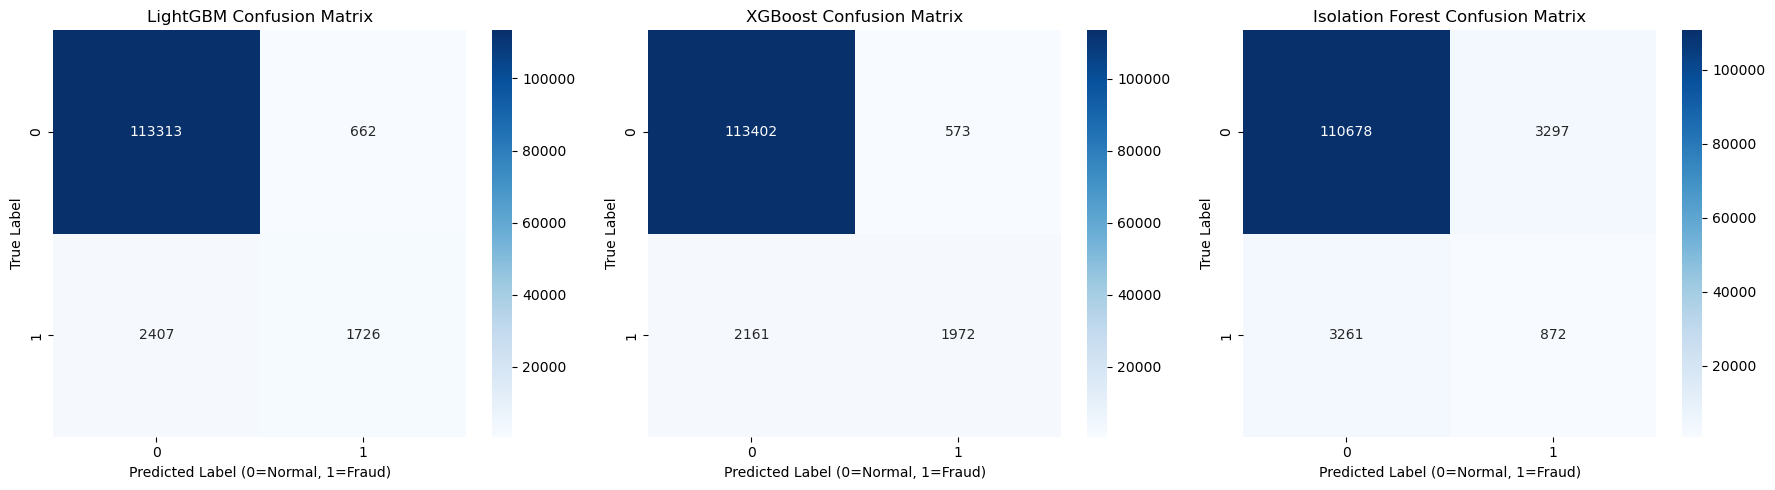

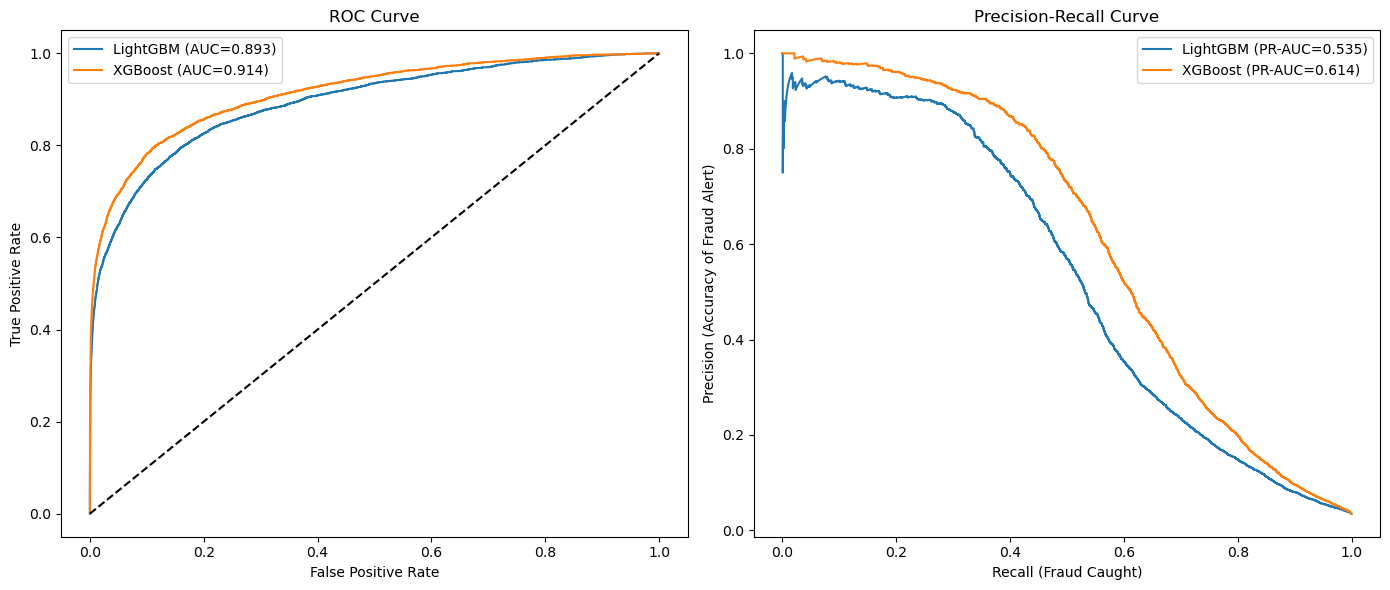

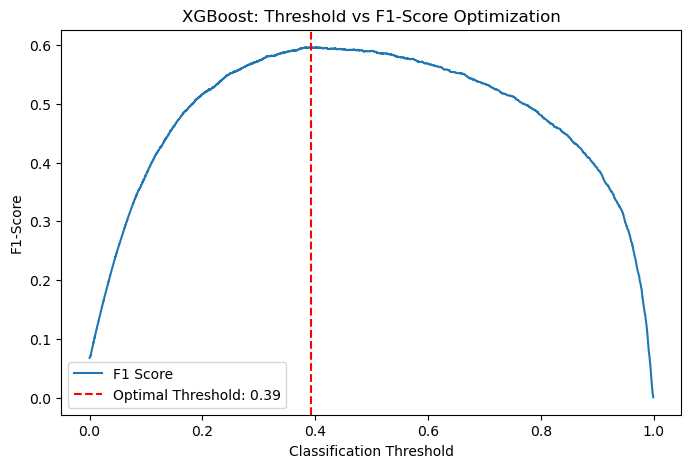


Advanced Optimization Result:
XGBoost Optimal Threshold: 0.3923
Max F1-Score Achievable: 0.5967
Task 3 Complete! We now have our best model and its optimal threshold.


In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, precision_recall_curve, auc
import numpy as np

print("Generating Task 3 Visualizations...")

# 1. Confusion Matrices for all 3 models
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
models_preds = [('LightGBM', y_pred_lgbm), ('XGBoost', y_pred_xgb), ('Isolation Forest', y_pred_iso)]

for ax, (name, y_pred) in zip(axes, models_preds):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax)
    ax.set_title(f'{name} Confusion Matrix')
    ax.set_xlabel('Predicted Label (0=Normal, 1=Fraud)')
    ax.set_ylabel('True Label')

plt.tight_layout()
plt.show()

# 2. ROC & Precision-Recall Curves (Comparing LightGBM and XGBoost)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# ROC Curve
fpr_lgb, tpr_lgb, _ = roc_curve(y_test, y_prob_lgbm)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb)

ax1.plot(fpr_lgb, tpr_lgb, label=f'LightGBM (AUC={roc_auc_score(y_test, y_prob_lgbm):.3f})')
ax1.plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC={roc_auc_score(y_test, y_prob_xgb):.3f})')
ax1.plot([0, 1], [0, 1], 'k--')
ax1.set_title('ROC Curve')
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')
ax1.legend()

# Precision-Recall Curve
prec_lgb, rec_lgb, _ = precision_recall_curve(y_test, y_prob_lgbm)
prec_xgb, rec_xgb, thresholds_xgb = precision_recall_curve(y_test, y_prob_xgb)

from sklearn.metrics import average_precision_score
ax2.plot(rec_lgb, prec_lgb, label=f'LightGBM (PR-AUC={average_precision_score(y_test, y_prob_lgbm):.3f})')
ax2.plot(rec_xgb, prec_xgb, label=f'XGBoost (PR-AUC={average_precision_score(y_test, y_prob_xgb):.3f})')
ax2.set_title('Precision-Recall Curve')
ax2.set_xlabel('Recall (Fraud Caught)')
ax2.set_ylabel('Precision (Accuracy of Fraud Alert)')
ax2.legend()

plt.tight_layout()
plt.show()

# 3. Threshold Optimization for Best Model (XGBoost)
# Calculate F1 scores for all thresholds to find the peak performance point
f1_scores = 2 * (prec_xgb * rec_xgb) / (prec_xgb + rec_xgb + 1e-9)
optimal_idx = np.argmax(f1_scores)
optimal_threshold = thresholds_xgb[optimal_idx]
optimal_f1 = f1_scores[optimal_idx]

plt.figure(figsize=(8, 5))
plt.plot(thresholds_xgb, f1_scores[:-1], label='F1 Score')
plt.axvline(x=optimal_threshold, color='red', linestyle='--', label=f'Optimal Threshold: {optimal_threshold:.2f}')
plt.title('XGBoost: Threshold vs F1-Score Optimization')
plt.xlabel('Classification Threshold')
plt.ylabel('F1-Score')
plt.legend()
plt.show()

print(f"\nAdvanced Optimization Result:")
print(f"XGBoost Optimal Threshold: {optimal_threshold:.4f}")
print(f"Max F1-Score Achievable: {optimal_f1:.4f}")
print("Task 3 Complete! We now have our best model and its optimal threshold.")

In [11]:
!pip install shap

Defaulting to user installation because normal site-packages is not writeable


1. SHAP TreeExplainer ban raha hai (XGBoost ka dimaag padhne ke liye)...
2. Global Summary Plot generate ho raha hai...


C:\Users\user\AppData\Local\Temp\ipykernel_19688\29300898.py:23: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values_sample, X_sample, feature_names=list(X.columns), max_display=20)


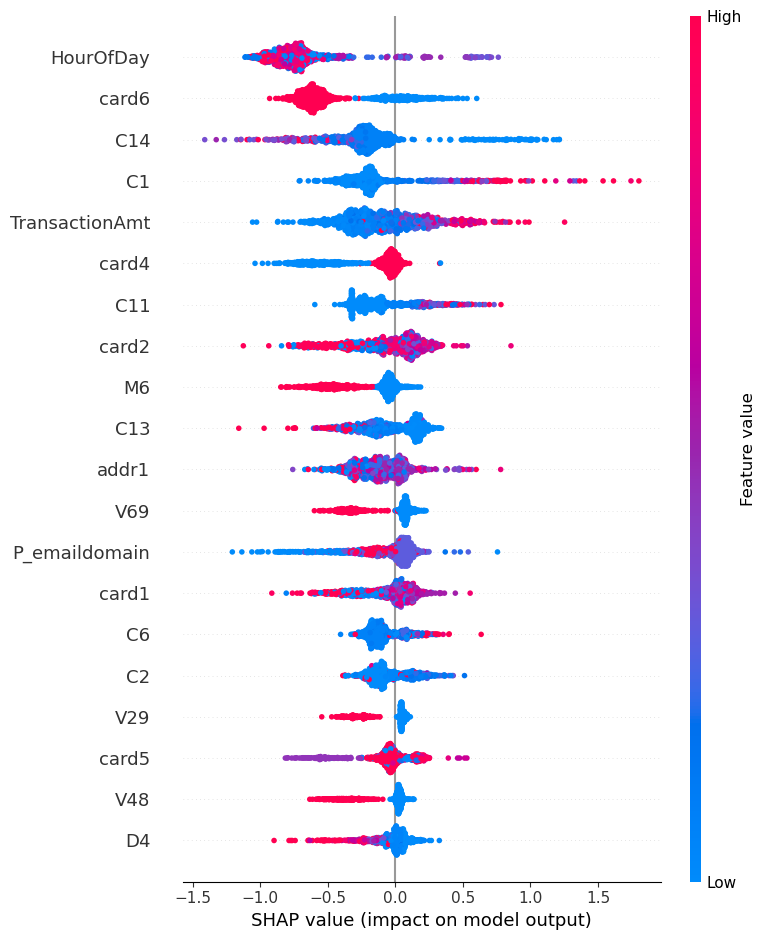

3. PDF Requirement: 3 Specific Transactions dhoondh rahe hain (Fraud, Borderline, Legitimate)...

--- Plotting SHAP Waterfall: 1. Confirmed Fraud Case ---


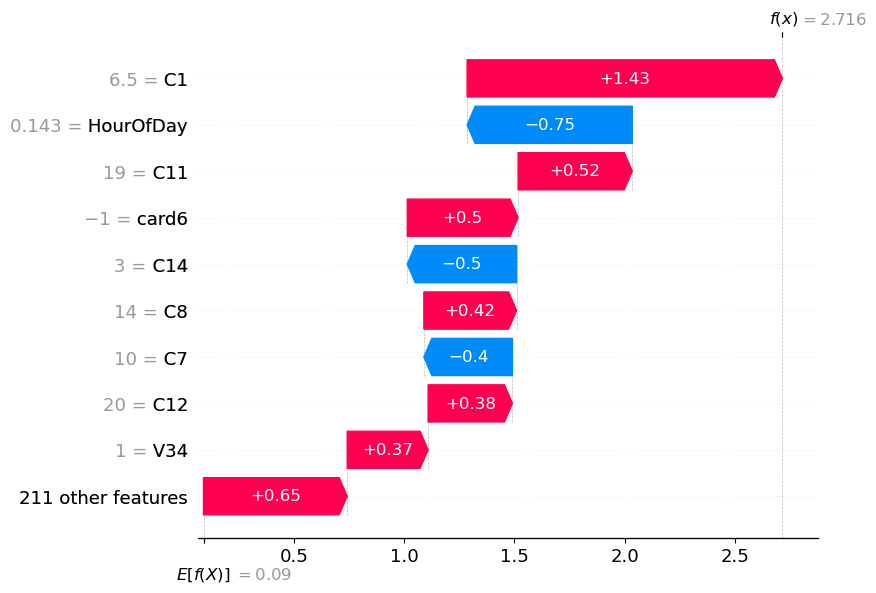


--- Plotting SHAP Waterfall: 2. Borderline Case ---


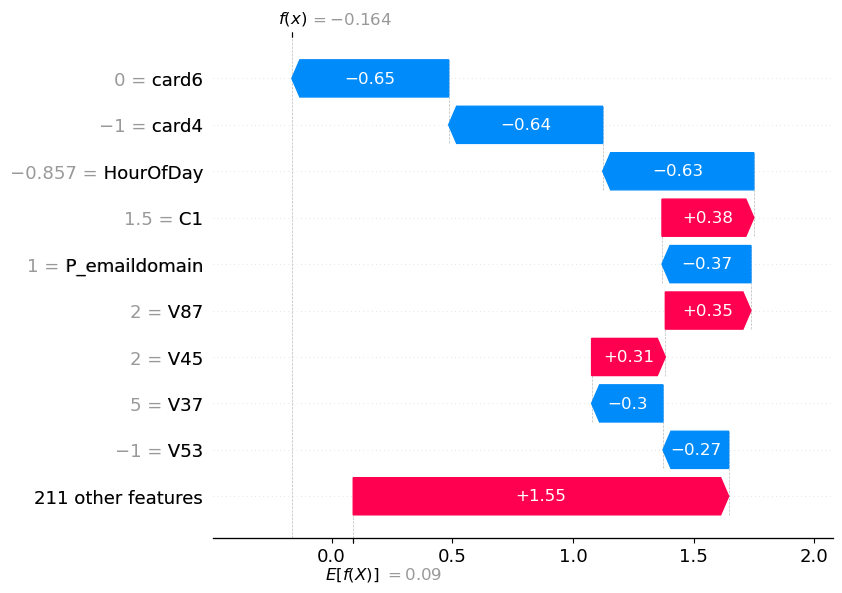


--- Plotting SHAP Waterfall: 3. Legitimate Transaction ---


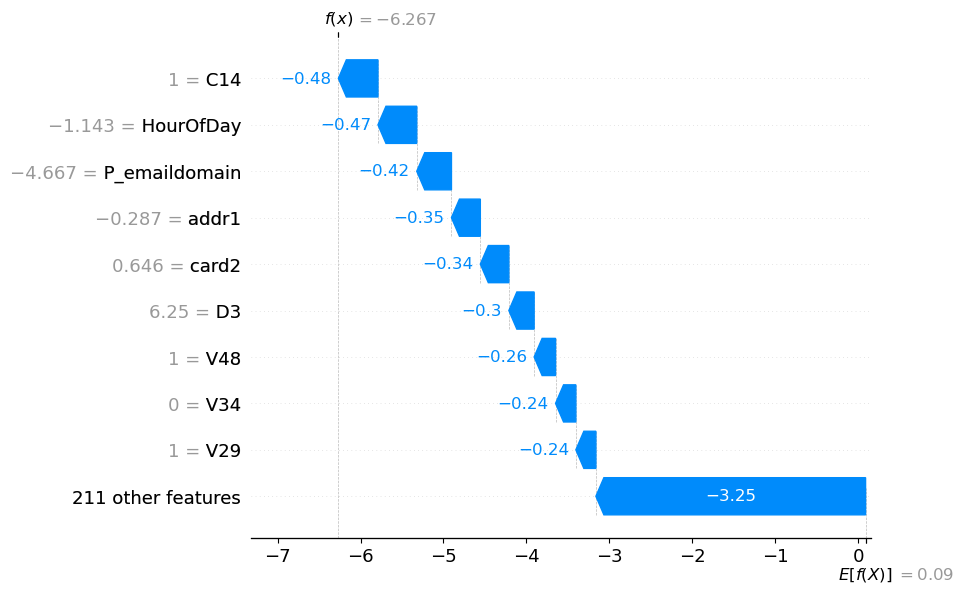


4. Generating SHAP Dependence Plot for 'TransactionAmt'...


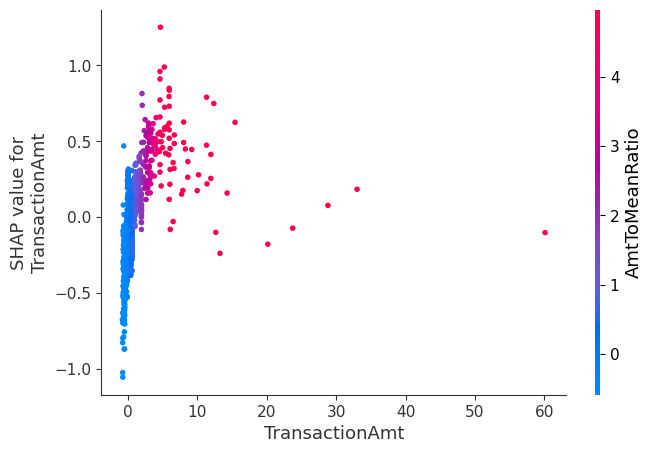


Task 4 Complete! SHAP Visualizations is ready.


In [13]:
import shap
import numpy as np
import matplotlib.pyplot as plt

# Notebook mein graphs load karne ke liye JS initialize karna
shap.initjs()

print("1. SHAP TreeExplainer ban raha hai (XGBoost ka dimaag padhne ke liye)...")
explainer = shap.TreeExplainer(xgb_model)

print("2. Global Summary Plot generate ho raha hai...")
# Code ko fast rakhne ke liye hum test data me se 1000 random transactions ka sample lenge
np.random.seed(42)
sample_indices = np.random.choice(X_test_scaled.shape[0], 1000, replace=False)
X_sample = X_test_scaled[sample_indices]

# In 1000 rows ka SHAP value calculate karna
shap_values_sample = explainer(X_sample)
shap_values_sample.feature_names = list(X.columns)

# Plot 1: Global Summary Plot (Top 20 Features)
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values_sample, X_sample, feature_names=list(X.columns), max_display=20)
plt.show()

print("3. PDF Requirement: 3 Specific Transactions dhoondh rahe hain (Fraud, Borderline, Legitimate)...")
# Poore test data ki probability calculate karna
probs = xgb_model.predict_proba(X_test_scaled)[:, 1]
y_test_array = y_test.values

# A. Confirmed Fraud (Asli mein 1 hai, aur Model ne > 80% prob di hai)
fraud_idx = np.where((y_test_array == 1) & (probs > 0.8))[0][0]
# B. Borderline Case (Probability exactly 0.50 ke aas paas hai)
border_idx = np.where(np.abs(probs - 0.5) < 0.05)[0][0]
# C. Legitimate Case (Asli mein 0 hai, aur model ne < 10% prob di hai)
legit_idx = np.where((y_test_array == 0) & (probs < 0.1))[0][0]

# In 3 cases ka data alag nikalna aur SHAP calculate karna
X_3_cases = X_test_scaled[[fraud_idx, border_idx, legit_idx]]
shap_values_3 = explainer(X_3_cases)
shap_values_3.feature_names = list(X.columns)

print("\n--- Plotting SHAP Waterfall: 1. Confirmed Fraud Case ---")
shap.plots.waterfall(shap_values_3[0])

print("\n--- Plotting SHAP Waterfall: 2. Borderline Case ---")
shap.plots.waterfall(shap_values_3[1])

print("\n--- Plotting SHAP Waterfall: 3. Legitimate Transaction ---")
shap.plots.waterfall(shap_values_3[2])

print("\n4. Generating SHAP Dependence Plot for 'TransactionAmt'...")
# Plot 5: Dependence Plot (Dekhna ki Amount badhne se fraud risk kaise badhta hai)
shap.dependence_plot("TransactionAmt", shap_values_sample.values, X_sample, feature_names=list(X.columns))

print("\nTask 4 Complete! SHAP Visualizations is ready.")

1. Segmenting Transactions into Risk Tiers...

2. Computing Stats for Each Tier (Count and Avg Amount)...


,Total_Transactions,Avg_TransactionAmt
Risk_Tier,,
Critical Risk,1635,121.879098
Suspicious,1539,140.468070
Clear,114934,134.958119



3. Creating Grouped Bar Chart...


C:\Users\user\AppData\Local\Temp\ipykernel_19688\966886145.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=tier_stats.index, y='Avg_TransactionAmt', data=tier_stats, palette=['red', 'orange', 'green'])


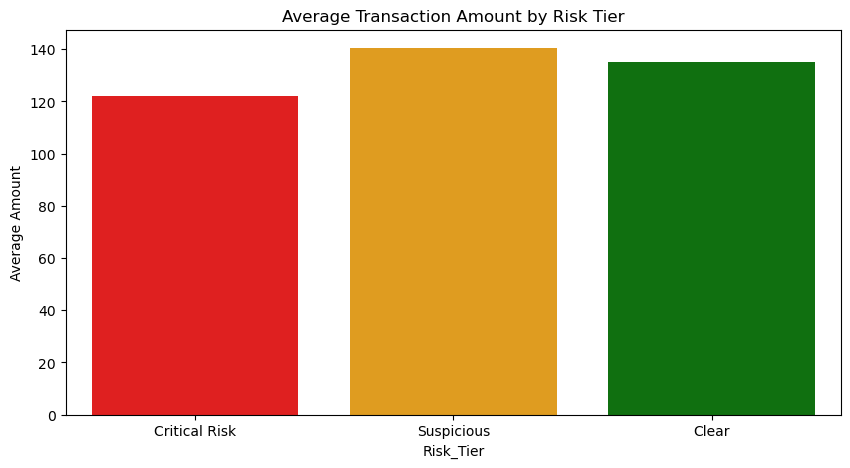


4. Top Fraud Patterns in 'Critical Risk' Tier:
- Most common Hour of Day for fraud: 23
- Average Amount for Critical Fraud: $121.88
- Device Risk Flag Distribution (in %):
 DeviceRisk
1    64.34
0    35.66

Task 5 Complete! Data analysis is done.


In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

print("1. Segmenting Transactions into Risk Tiers...")
# Generate live probabilities on the XGBoost test set
test_probs = xgb_model.predict_proba(X_test_scaled)[:, 1]

# Create a copy of the unscaled test data for business analysis
analysis_df = X_test.copy()
analysis_df['Fraud_Probability'] = test_probs
analysis_df['True_Label'] = y_test.values

# Assign Risk Tiers based on PDF requirements
conditions = [
    (analysis_df['Fraud_Probability'] >= 0.75),
    (analysis_df['Fraud_Probability'] >= 0.40) & (analysis_df['Fraud_Probability'] < 0.75),
    (analysis_df['Fraud_Probability'] < 0.40)
]
choices = ['Critical Risk', 'Suspicious', 'Clear']
analysis_df['Risk_Tier'] = np.select(conditions, choices, default='Clear')

print("\n2. Computing Stats for Each Tier (Count and Avg Amount)...")
# Group by Risk Tier to calculate total transactions and average amount
tier_stats = analysis_df.groupby('Risk_Tier').agg(
        Total_Transactions=('Fraud_Probability', 'count'),
        Avg_TransactionAmt=('TransactionAmt', 'mean')
).reindex(['Critical Risk', 'Suspicious', 'Clear'])

display(tier_stats)

print("\n3. Creating Grouped Bar Chart...")
# Plot average transaction amount for each risk tier
plt.figure(figsize=(10, 5))
sns.barplot(x=tier_stats.index, y='Avg_TransactionAmt', data=tier_stats, palette=['red', 'orange', 'green'])
plt.title('Average Transaction Amount by Risk Tier')
plt.ylabel('Average Amount')
plt.show()

print("\n4. Top Fraud Patterns in 'Critical Risk' Tier:")
# Filter only the Critical Risk transactions for pattern analysis
critical_risk_df = analysis_df[analysis_df['Risk_Tier'] == 'Critical Risk']

print(f"- Most common Hour of Day for fraud: {critical_risk_df['HourOfDay'].mode()[0]:.0f}")
print(f"- Average Amount for Critical Fraud: ${critical_risk_df['TransactionAmt'].mean():.2f}")
print("- Device Risk Flag Distribution (in %):\n", (critical_risk_df['DeviceRisk'].value_counts(normalize=True) * 100).round(2).to_string())

print("\nTask 5 Complete! Data analysis is done.")

In [15]:
import joblib
import os
import pandas as pd

print("1. Creating the 'dashboard' folder...")
# Create a folder named 'dashboard' in your current directory
os.makedirs("dashboard", exist_ok=True)

print("2. Saving the trained XGBoost model...")
# Export the best model so the web app can use it
joblib.dump(xgb_model, "dashboard/xgb_model.pkl")

print("3. Preparing a sample dataset for the live dashboard...")
# Copy test data and attach real labels, predicted probabilities, and TransactionIDs
dashboard_data = X_test.copy()
dashboard_data['isFraud'] = y_test.values
dashboard_data['Fraud_Probability'] = xgb_model.predict_proba(X_test_scaled)[:, 1]

# Recover the original TransactionID from the main 'df' using the test index
dashboard_data['TransactionID'] = df.loc[X_test.index, 'TransactionID'].values

# Save this data as a CSV file inside the dashboard folder
dashboard_data.to_csv("dashboard/dashboard_data.csv", index=False)

print("\nExport Complete! Model and Data are successfully saved in the 'dashboard' folder.")

1. Creating the 'dashboard' folder...
2. Saving the trained XGBoost model...
3. Preparing a sample dataset for the live dashboard...

Export Complete! Model and Data are successfully saved in the 'dashboard' folder.
